In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import os
from mypackages.eRDF import *
from tqdm import tqdm 
from mypackages.edp_processing import peak_calibration

from matplotlib import rcParams, cycler
from matplotlib.ticker import AutoMinorLocator

from mypackages.plot_style import set_plot_style

set_plot_style()

The calculated calibration factor ds: 0.00743649587727647


<function matplotlib.pyplot.show(close=None, block=None)>

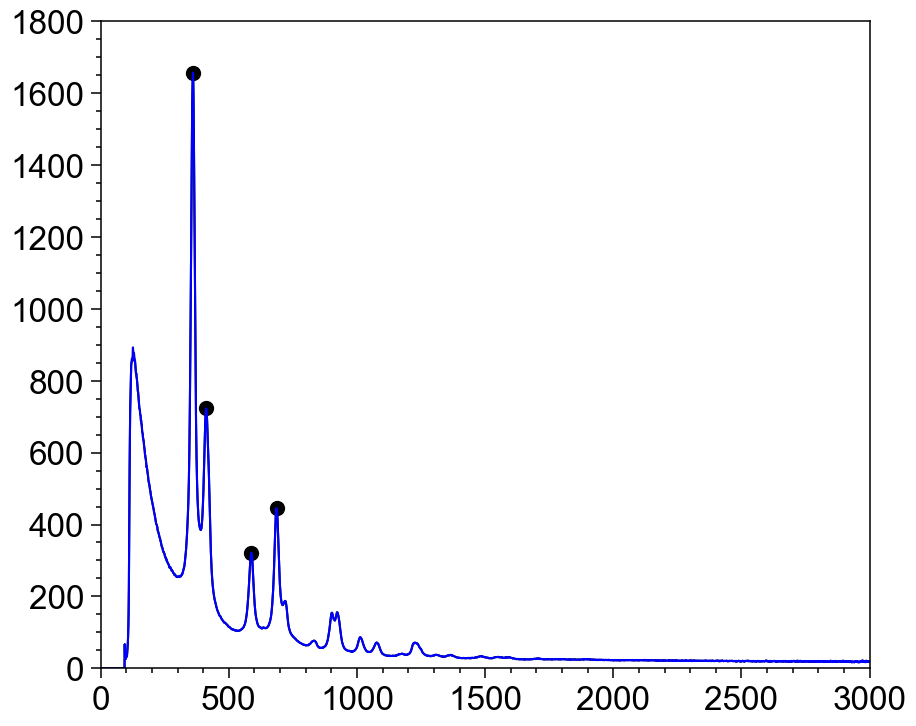

In [2]:
#gold peak calibration
from scipy.signal import find_peaks

path = r"../../../data\processed\ePDF\Au"

#end_name = 'Au_end.csv'
start_name = 'Au_start.csv'

df1 = pd.read_csv(os.path.join(path, start_name), header = None)
#df2 = pd.read_csv(os.path.join(path, end_name), header = None)

data_start = df1[0].values
#data_end = df2[0].values

peaks_start, _ = find_peaks(data_start, distance = 40, height=300)
#peaks_end, _ = find_peaks(data_end, distance = 40, height=500)



calibration = peak_calibration(pixel_positions = peaks_start[3:7])
#calibration_end = peak_calibration(pixel_positions = peaks_end[1:5])

#calibration = (calibration_start +calibration_end)/2

#peaks_end, _ = find_peaks(data_end, distance = 1, height=500)

plt.plot(data_start)
plt.plot(df1[0].values)
plt.scatter(peaks_start[3:7], data_start[peaks_start[3:7]])
plt.show

In [ ]:
from mypackages.eRDF import read_discus_fit_file

data = read_discus_fit_file('/home/ABTLUS/victor.secco/DISCUS/EXP2PDF/DATA/RACK_04_P_ZnO_AC_merge.iq')

calibration = data['r'].values[1]-data['r'].values[0]

In [ ]:
ds = (calibration)/(2*math.pi) #AuNPs

CdSe =  {1: [30, 1], 2: [8, 1],}
Magnetite = {1: [26, 3], 2: [8, 4],}
sdf
#path = '/home/ABTLUS/victor.secco/data_processing/ED/CdSe_ePDF/CDSe_Inorg_Lig/'
#df1 = pd.read_csv(os.path.join(path, 'CdSe_S2-.csv'), header=None)

#raw_data = df1[120].values
start = int(data.shape[0]*0.03)
end =  int(data.shape[0]*0.8)


dp1 = DataProcessor(data['gr'].values, 1, start, end, ds, CdSe, region = 0)
 

_iq = dp1.iq
_sq, _fq = dp1.SQ_PhiQ(_iq, 0)
_r, _Gr = dp1.Gr(_fq, rmax=80, dr=0.05)

_Gr_Lorch, _ = dp1.low_r_correction(_Gr, 0.025, _r, r_cut = 2)


dp1.plot_results(_sq, _fq, _Gr, _r, _Gr, 0)


NameError: name 'data' is not defined

Text(0.5, 0, 'r (Å)')

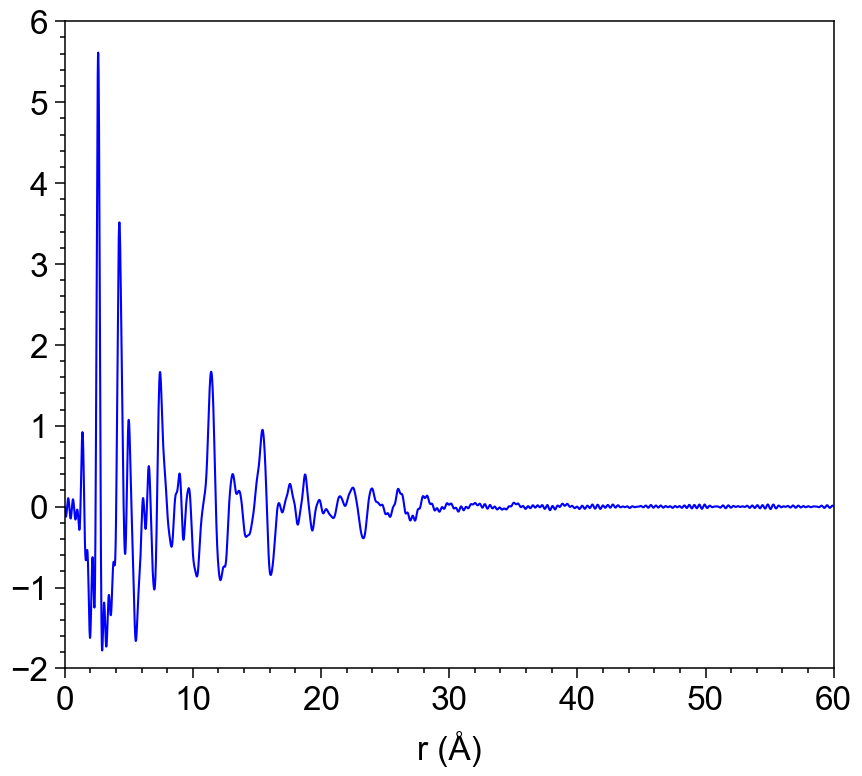

In [2]:
df = pd.read_csv(r'../../../data\processed\ePDF\CdSe\fq_pca_CdSe_P5.csv', header=0,sep="\t")


q, _fq = df["q"].values, df["sq"].values

_r, _Gr = calculate_Gr(q, _fq, rmax=60, dr=0.01)

_r = np.array(_r, dtype=np.float64)
_Gr = np.array(_Gr, dtype=np.float64)

plt.plot(_r, _Gr, label='CdSe', color='blue')
plt.xlabel('r (Å)') 